# Privacy and Governance Analysis
## Analysis Overview

This notebook analyzes potential privacy and fairness issues in a loan approval system.

The analysis focuses on:

- identifying sensitive attributes and personally identifiable information (PII)
- evaluating whether approval decisions differ across gender groups
- computing the Disparate Impact Ratio (DIR) to assess potential bias
- examining variables such as income or ZIP code that may act as proxy indicators

The objective is to evaluate potential risks related to bias, discrimination, and privacy from a data governance perspective.


## 1 - Import libraries

We import the standard libraries for data processing and visualization.

These tools enable dataset inspection, fairness metric computation, and governance reporting through plots and tables.

In [570]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - Load and normalize the dataset

The dataset is provided as a **nested JSON**.
We load the file and use `pd.json_normalize()` to create a tabular structure suitable for analysis.

This is a key governance step because governance controls (privacy/fairness checks) require clear visibility of all fields.

In [571]:
with open("../data/raw_credit_applications.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
df.columns
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


## 3 — Identify sensitive attributes, PII and GDPR obligations


We classify the dataset's attributes into three risk categories:

- **PII** (e.g., SSN, email, IP) → Privacy and re-identification risks.
- **Sensitive Attributes** (e.g., gender, DOB) → Fairness and bias risks (strictly regulated under GDPR Art. 9).
- **Proxy Variables** (e.g., ZIP code) → Potential indirect discrimination.

Mapping these directly to **GDPR Articles**  provides the legal framework for our subsequent controls.

In [572]:
governance_data = {
    "Attribute": [
        "applicant_info.full_name",
        "applicant_info.ssn",
        "applicant_info.email",
        "applicant_info.ip_address",
        "applicant_info.gender",
        "applicant_info.date_of_birth",
        "applicant_info.zip_code"
    ],
    "Category": [
        "PII (Direct)",
        "PII (Highly Sensitive)",
        "PII (Direct)",
        "PII (Online)",
        "Sensitive Attribute",
        "Sensitive Attribute",
        "Sensitive Proxy"
    ],
    "Risk Type": [
        "Personal identification",
        "Identity exposure",
        "Personal identification",
        "User tracking",
        "Gender discrimination",
        "Age discrimination",
        "Proxy discrimination"
    ],
    "GDPR Obligations": [
        "Art. 6, Art. 5(1)(c) (Minimization)",
        "Art. 6, Art. 5(1)(c), Art. 32 (Requires Hashing)",
        "Art. 6, Art. 5(1)(c) (Minimization)",
        "Art. 6 (Legitimate interest), Art. 5(1)(c)",
        "Art. 9 (Strictly limited, used for bias auditing)",
        "Art. 5(1)(c), Art. 5(1)(e) (Storage limitation)",
        "Art. 5(1)(c) (Data minimization)"
    ]
}

governance_table = pd.DataFrame(governance_data)
display(governance_table)

,Attribute,Category,Risk Type,GDPR Obligations
0,applicant_info.full_name,PII (Direct),Personal identification,"Art. 6, Art. 5(1)(c) (Minimization)"
1,applicant_info.ssn,PII (Highly Sensitive),Identity exposure,"Art. 6, Art. 5(1)(c), Art. 32 (Requires Hashing)"
2,applicant_info.email,PII (Direct),Personal identification,"Art. 6, Art. 5(1)(c) (Minimization)"
3,applicant_info.ip_address,PII (Online),User tracking,"Art. 6 (Legitimate interest), Art. 5(1)(c)"
4,applicant_info.gender,Sensitive Attribute,Gender discrimination,"Art. 9 (Strictly limited, used for bias auditing)"
5,applicant_info.date_of_birth,Sensitive Attribute,Age discrimination,"Art. 5(1)(c), Art. 5(1)(e) (Storage limitation)"
6,applicant_info.zip_code,Sensitive Proxy,Proxy discrimination,Art. 5(1)(c) (Data minimization)


## 4 — Privacy control: Pseudonymization of PII

Following the regulatory obligations mapped in the previous step, we must mitigate the privacy risks associated with direct identifiers before proceeding with analytics.

In our dataset, these personal attributes are originally stored inside a nested `applicant_info` object. To enable GDPR-compliant pseudonymization, these direct PII fields (`full_name`, `email`, `ssn`, and `ip_address`) are first extracted and then replaced with salted SHA-256 hashes. This creates secure columns (such as `applicant_info.email_hash`) while completely removing the raw PII from our working dataset (`df_privacy`). This approach supports data minimization and security in line with GDPR Articles 5(1)(c) and 32.



In [573]:
import os
import hashlib

PII_COLS = [
    "applicant_info.full_name",   # if present in dataset
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address"
]

PII_COLS = [c for c in PII_COLS if c in df.columns]


SALT = os.getenv("PSEUDO_SALT")


if not SALT:
    SALT = "DEMO_ONLY_CHANGE_ME_AND_STORE_SECURELY"


def salted_sha256(value, salt):
    """
    Stable pseudonymization using salted SHA-256.
    Returns NA if value is missing.
    """
    if pd.isna(value):
        return pd.NA

    value = str(value).strip()

    if value == "":
        return pd.NA

    return hashlib.sha256((salt + value).encode("utf-8")).hexdigest()


for col in PII_COLS:
    df[col + "_hash"] = df[col].apply(lambda x: salted_sha256(x, SALT))



df_privacy = df.copy()
df_privacy = df_privacy.drop(columns=PII_COLS, errors="ignore")

print("=== Pseudonymization completed ===")
print("Columns hashed:", [c + "_hash" for c in PII_COLS])
print("Raw PII removed from df_privacy:", PII_COLS)


if PII_COLS:
    display(df_privacy[[c + "_hash" for c in PII_COLS]].head())
else:
    print("No PII columns found in dataset.")

=== Pseudonymization completed ===
Columns hashed: ['applicant_info.full_name_hash', 'applicant_info.email_hash', 'applicant_info.ssn_hash', 'applicant_info.ip_address_hash']
Raw PII removed from df_privacy: ['applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address']


,applicant_info.full_name_hash,applicant_info.email_hash,applicant_info.ssn_hash,applicant_info.ip_address_hash
0,ba096c86c1cfc125bcfad3f50803ac275c9bf7887b7171...,36cbac2c92613dcc1347b07435fad13f98f5532e42f0e5...,ddb61615f4cae0cde238021b12800ae40cad93d121884d...,bc05ce55e86f0abe9fc721a7eda3bd65b2a33d944d74bd...
1,b8338fc3222a6697c64dc3b83f9992674b7091cbab264b...,1688be51d7445df37715215c7e8dc85752992b95de8658...,a1db7207c57f46a5502e8b2e755f759bc12a94c1cf44ec...,10feb108356840f2feec1816ef8b453821d300a21e8d48...
2,b4cd70fd0380b676fddf9f0e3a4a505ac7f551a3cd0bdd...,529b0c5c5be077653e1535482304aead1153768b42787b...,7c7faed93e3268b1cb11feb41d2473642358877b7a7732...,a868237a38ddb9192185a811caff3d2b88e4632415ced0...
3,e9e031b167e684179e116dd9e7c4676c0b4a042d69b92f...,8712260069d9d386f37f649ffec45f33ecb97fd9bc1e93...,a19a4afe67f8872cf9d02a46860f89fb0fb21a11cf7378...,897b66c648382fce39c3f965be02aa8cbd827d1b33c782...
4,37da1ce2343a5d8267b1442fd83f3cf788ad3f445dad98...,f5f2357689208cca22e21323a224fd4293d570187d43ff...,77695ac7b0247e1b31cd5d7776a0d1521c6cef04c92a42...,8ecd1fd8dfd4d155a8c47bfb477a775aa80f6a2bbb713b...


In [574]:
df_privacy

,_id,spending_behavior,processing_timestamp,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,...,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,applicant_info.full_name_hash,applicant_info.email_hash,applicant_info.ssn_hash,applicant_info.ip_address_hash
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Male,2001-03-09,10036,73000,23,0.20,31212,...,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,ba096c86c1cfc125bcfad3f50803ac275c9bf7887b7171...,36cbac2c92613dcc1347b07435fad13f98f5532e42f0e5...,ddb61615f4cae0cde238021b12800ae40cad93d121884d...,bc05ce55e86f0abe9fc721a7eda3bd65b2a33d944d74bd...
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,M,1992-03-31,10032,78000,51,0.18,17915,...,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,b8338fc3222a6697c64dc3b83f9992674b7091cbab264b...,1688be51d7445df37715215c7e8dc85752992b95de8658...,a1db7207c57f46a5502e8b2e755f759bc12a94c1cf44ec...,10feb108356840f2feec1816ef8b453821d300a21e8d48...
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Male,1989-10-24,10075,61000,41,0.21,37909,...,NaN,vacation,3.7,59000.0,NaN,NaN,b4cd70fd0380b676fddf9f0e3a4a505ac7f551a3cd0bdd...,529b0c5c5be077653e1535482304aead1153768b42787b...,7c7faed93e3268b1cb11feb41d2473642358877b7a7732...,a868237a38ddb9192185a811caff3d2b88e4632415ced0...
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Male,1983-04-25,10077,103000,70,0.35,0,...,NaN,NaN,4.3,34000.0,NaN,NaN,e9e031b167e684179e116dd9e7c4676c0b4a042d69b92f...,8712260069d9d386f37f649ffec45f33ecb97fd9bc1e93...,a19a4afe67f8872cf9d02a46860f89fb0fb21a11cf7378...,897b66c648382fce39c3f965be02aa8cbd827d1b33c782...
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,M,1999-05-21,10080,57000,14,0.23,31763,...,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,37da1ce2343a5d8267b1442fd83f3cf788ad3f445dad98...,f5f2357689208cca22e21323a224fd4293d570187d43ff...,77695ac7b0247e1b31cd5d7776a0d1521c6cef04c92a42...,8ecd1fd8dfd4d155a8c47bfb477a775aa80f6a2bbb713b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,app_468,"[{'category': 'Transportation', 'amount': 701}]",NaN,Male,1999-05-23,10046,22000,35,0.35,8982,...,insufficient_credit_history,NaN,NaN,NaN,NaN,NaN,bdbf5371d6c7c03de678ea4552a9062ab4a6ff5e55b08a...,7e0a7d56ba08654e4ad52a9dec5239196cbd92701c4400...,6bc8977db4671870f2612bde8011e9c0f31f3e11ccc270...,5a9be6a8dc628ca4a4693540f1ddf179227315dd3c206c...
498,app_192,"[{'category': 'Healthcare', 'amount': 650}]",2024-01-15T00:00:00Z,Male,11/15/1985,10088,78000,40,0.22,34292,...,NaN,NaN,6.0,18000.0,NaN,NaN,f5004447abbeee87d7e9a101c659f3b8358c51af79249d...,aaf242ca806b0ed8e35af9a4c1e89bad87780adbf5ecd1...,7b36636682b09d26d027f05d309e6b990b76cacf437494...,caa644be4be11da102a8c474e877fdbcdf26a49241f797...
499,app_234,"[{'category': 'Insurance', 'amount': 526}]",NaN,Male,1976/01/29,10090,96000,60,0.30,38703,...,algorithm_risk_score,education,NaN,NaN,NaN,NaN,9b2cb7ac48b74fc7b8aa49bc8e9809b49f4b6439d6a3a0...,e85c9f93191e73bad1a68effcdf4c94f9e19d952362439...,719ed54942cf82cc8d2dda512877a6f6ed6298391fb107...,fa204341e34ac11f49ed7391d219452d574c92a3a01189...
500,app_306,"[{'category': 'Insurance', 'amount': 490}]",NaN,Female,1978-07-26,90227,106000,80,0.29,63560,...,NaN,NaN,3.1,57000.0,NaN,NaN,1aef84c80ff19756bd9bf04bb48edc96b017772182bdbb...,cb29e0d6ef068443e14c70e3cde42add5d86410e85b9d7...,5cf12d2c113c55ad50522d03c56bf1341d189b21f45e1e...,f445fe0cb5441d94e327da31639240a9d0074c01ae227d...


## Fairness Metrics — Scope and Limitations

The fairness evaluation focuses on outcome-based metrics such as Demographic Parity and the Disparate Impact Ratio (DIR).

Metrics such as Equalized Odds and Predictive Parity cannot be computed in this analysis because the dataset does not include ground-truth outcomes (e.g., whether loans were actually repaid or defaulted).

## 5 — Outcome disparity and fairness metric (DIR)

We compute the approval rate by gender to detect disparities in outcomes.

Then we compute the Disparate Impact Ratio (DIR):

DIR = Approval Rate (Female) / Approval Rate (Male)

A commonly used guideline is the 80% rule: if DIR < 0.8, outcomes may indicate potential disparate impact.

A DIR below the threshold signals a potential adverse impact (systematic outcome disparity across groups). It does not, by itself, prove an unlawful decision process, but it is a compliance trigger: it becomes relevant under GDPR principles, in particular Article 5(1) (lawfulness, fairness and transparency), Article 5(2) (accountability), and may be relevant for Article 22 (automated decision-making with legal or similarly significant effects).

In addition, since credit scoring is treated as a high-risk AI use case under the EU AI Act, a fairness red flag such as DIR < 0.8 directly impacts core governance requirements, including:
- risk management
- data governance and data quality
- technical documentation and transparency
- human oversight (human-in-the-loop)


In [575]:
import json
import pandas as pd
import numpy as np

# -----------------------------
# Load original raw dataset (JSON -> tabular)
# -----------------------------
with open("../data/raw_credit_applications.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)

# -----------------------------
# Minimal normalization needed to compute fairness metrics reliably
# (does NOT remove rows except invalid gender/decision)
# -----------------------------

# 1) Clean/standardize gender into a derived column (keeps original intact)
g = (
    df["applicant_info.gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["gender_clean"] = g.map({
    "m": "Male",
    "male": "Male",
    "1": "Male",
    "f": "Female",
    "female": "Female",
    "2": "Female",
})

# 2) Ensure decision is clean numeric/bool-like (0/1)
#    (handles True/False, 0/1, "true"/"false", etc.)
decision_raw = df["decision.loan_approved"]

if decision_raw.dtype == bool:
    df["loan_approved_clean"] = decision_raw.astype(int)
else:
    df["loan_approved_clean"] = (
        decision_raw.astype(str).str.strip().str.lower()
        .replace({"true": 1, "false": 0, "yes": 1, "no": 0})
    )
    df["loan_approved_clean"] = pd.to_numeric(df["loan_approved_clean"], errors="coerce")

# 3) Keep only records usable for the metric
df_fair = df[df["gender_clean"].isin(["Male", "Female"])].copy()
df_fair = df_fair.dropna(subset=["loan_approved_clean"])

# -----------------------------
# Approval rate + gap + Disparate Impact Ratio (DIR)
# -----------------------------
approval_by_gender = df_fair.groupby("gender_clean")["loan_approved_clean"].mean()

female_rate = approval_by_gender.get("Female", np.nan)
male_rate = approval_by_gender.get("Male", np.nan)

print("=== Approval Rate by Gender (cleaned for metric) ===")
print(approval_by_gender)

print("\n=== Approval Rate (percent) ===")
print(f"Female approval rate: {female_rate:.4f} ({female_rate * 100:.2f}%)")
print(f"Male approval rate:   {male_rate:.4f} ({male_rate * 100:.2f}%)")

diff_pp = (male_rate - female_rate) * 100
print("\n=== Approval Gap ===")
print(f"Difference (Male - Female): {diff_pp:.2f} percentage points")

DIR = female_rate / male_rate
print("\n=== Disparate Impact Ratio (DIR) ===")
print(f"DIR = {DIR:.3f}")

print("\n=== Fairness Interpretation ===")
if np.isfinite(DIR) and DIR < 0.8:
    print("The DIR is below the 0.8 fairness threshold (80% rule).")
    print("This may indicate potential disparate impact / gender bias risk.")
else:
    print("DIR is at/above 0.8 or not computable with current data.")
    print("No disparate impact flagged by this metric alone.")

# Optional: show how many records were used
print("\n=== Sample sizes used ===")
print(df_fair["gender_clean"].value_counts())

=== Approval Rate by Gender (cleaned for metric) ===
gender_clean
Female    0.505976
Male      0.657258
Name: loan_approved_clean, dtype: float64

=== Approval Rate (percent) ===
Female approval rate: 0.5060 (50.60%)
Male approval rate:   0.6573 (65.73%)

=== Approval Gap ===
Difference (Male - Female): 15.13 percentage points

=== Disparate Impact Ratio (DIR) ===
DIR = 0.770

=== Fairness Interpretation ===
The DIR is below the 0.8 fairness threshold (80% rule).
This may indicate potential disparate impact / gender bias risk.

=== Sample sizes used ===
gender_clean
Female    251
Male      248
Name: count, dtype: int64


## 6 — Visualize Disparate Impact Ratio

We visualize the DIR and the fairness threshold (0.8) to make the governance conclusion more interpretable.

Visual thresholds improve communication of fairness risks to non-technical stakeholders (a key governance requirement).


=== Disparate Impact Ratio (DIR) ===
DIR (Female/Male) = 0.770
 DIR < 0.8 (80% rule) → potential adverse impact / disparate impact risk.


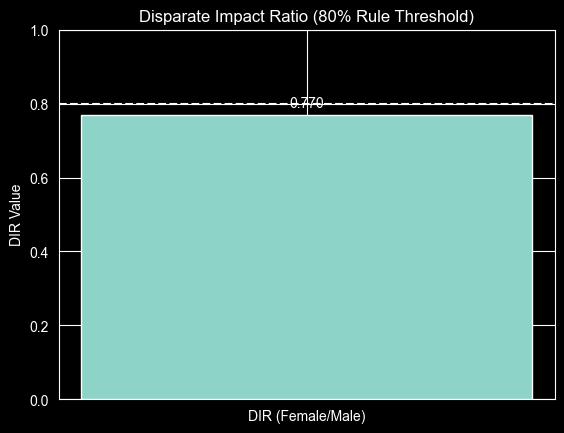

In [576]:
print("\n=== Disparate Impact Ratio (DIR) ===")
print(f"DIR (Female/Male) = {DIR:.3f}")

threshold = 0.8
if DIR < threshold:
    print(" DIR < 0.8 (80% rule) → potential adverse impact / disparate impact risk.")
else:
    print("DIR ≥ 0.8 → no adverse impact detected by this metric.")

plt.figure()
plt.bar(["DIR (Female/Male)"], [DIR])
plt.axhline(threshold, linestyle="--")
plt.title("Disparate Impact Ratio (80% Rule Threshold)")
plt.ylabel("DIR Value")
plt.ylim(0, 1)


plt.text(0, DIR + 0.02, f"{DIR:.3f}", ha="center")

plt.show()

## 7 — Outcome Disparity

We analyze the difference in approval rates to verify whether the system penalizes one gender over the other.

By calculating the approval gap  we quantify the "Outcome Disparity." This allows us to measure, in a direct and intuitive way, how the automated system treats men and women differently.

From a governance and oversight perspective:
- This analysis is essential for **Art. 10 of the EU AI Act**, which mandates monitoring whether AI systems produce disproportionate results for a specific sex.
- A significant gap is a  signal of potential violation of the **GDPR Principle of Fairness (Art. 5)**.
- This chart enables immediate communication to bank stakeholders regarding the extent of gender discrimination found within the model.

The bar chart below visualizes these percentages, making the gap between the two sexes immediately evident for auditing purposes.

=== Outcome disparity (Approval rate by gender) ===
gender_clean
Female    0.505976
Male      0.657258
Name: decision.loan_approved, dtype: float64

Female approval rate: 50.60%
Male approval rate:   65.73%
Approval gap (Male - Female): 15.13 percentage points


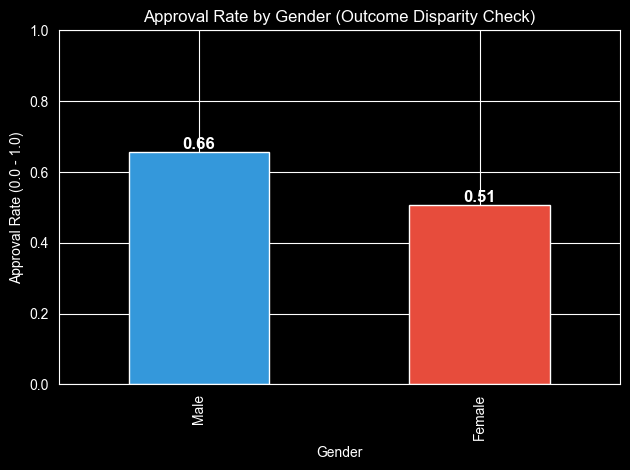

In [577]:
approval_rates = df.groupby("gender_clean")["decision.loan_approved"].mean()
female_rate = approval_rates.loc["Female"]
male_rate   = approval_rates.loc["Male"]
gap_pp = (male_rate - female_rate) * 100
print("=== Outcome disparity (Approval rate by gender) ===")
print(approval_rates)

print("\nFemale approval rate: {:.2f}%".format(female_rate * 100))
print("Male approval rate:   {:.2f}%".format(male_rate * 100))
print("Approval gap (Male - Female): {:.2f} percentage points".format(gap_pp))
ax = approval_rates.reindex(["Male", "Female"]).plot(kind="bar", color=['#3498db', '#e74c3c'])
plt.title("Approval Rate by Gender (Outcome Disparity Check)")
plt.xlabel("Gender")
plt.ylabel("Approval Rate (0.0 - 1.0)")
plt.ylim(0, 1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight='bold')
plt.tight_layout()
plt.show()

## 8 — Proxy discrimination check (ZIP code)


We verify whether the ZIP code acts as a proxy variable, causing indirect discrimination based on the geographic location of users.


The data shows a critical disparity in approval rates:
- **Maximum Rate (100%):** ZIP codes such as "10092" and "10012" (total approval).
- **Minimum Rate (28-33%):** ZIP codes such as "10096 (0.28)" and "10019 (0.33)".


 We have a regulatory obligation to verify whether low-approval ZIP codes coincide with low-income areas or minority populations. If confirmed, the model is practicing illegal indirect discrimination (violating Art. 10 EU AI Act).

In [578]:
if "df_g" not in globals():
    df_g = df[df["gender_clean"].isin(["Male", "Female"])].copy()
    df_g["financials.annual_income"] = pd.to_numeric(df_g["financials.annual_income"], errors="coerce")
    df_g["decision.loan_approved"] = pd.to_numeric(df_g["decision.loan_approved"], errors="coerce")
    df_g = df_g.dropna(subset=["decision.loan_approved", "gender_clean"])


df_g["zip_clean"] = df_g["applicant_info.zip_code"].astype(str).str.strip()


zip_stats = (
    df_g.groupby("zip_clean")["decision.loan_approved"]
    .agg(n="count", approval_rate="mean")
    .sort_values("n", ascending=False)
)

print("=== ZIP summary (top 10 by volume) ===")
display(zip_stats.head(10))

# Choose an appropriate minimum sample size automatically
max_n = int(zip_stats["n"].max()) if len(zip_stats) > 0 else 0
if max_n >= 10:
    min_n = 10
elif max_n >= 5:
    min_n = 5
elif max_n >= 3:
    min_n = 3
else:
    min_n = 1

zip_stats_filtered = zip_stats[zip_stats["n"] >= min_n].copy()

print(f"\nUsing min_n = {min_n} (max ZIP count in dataset = {max_n})")
print(f"ZIP codes kept for comparison: {zip_stats_filtered.shape[0]}")

print("\n=== ZIP codes with lowest approval rate (filtered) ===")
display(zip_stats_filtered.sort_values("approval_rate").head(10))

print("\n=== ZIP codes with highest approval rate (filtered) ===")
display(zip_stats_filtered.sort_values("approval_rate", ascending=False).head(10))

=== ZIP summary (top 10 by volume) ===


,n,approval_rate
zip_clean,,
10048,8,0.750000
90284,7,0.428571
10096,7,0.285714
10020,6,0.666667
10057,6,0.500000
10019,6,0.333333
10004,6,1.000000
10070,5,0.800000
10044,5,0.400000



Using min_n = 5 (max ZIP count in dataset = 8)
ZIP codes kept for comparison: 19

=== ZIP codes with lowest approval rate (filtered) ===


,n,approval_rate
zip_clean,,
10096,7,0.285714
10019,6,0.333333
10003,5,0.400000
10044,5,0.400000
90284,7,0.428571
10057,6,0.500000
10041,5,0.600000
10002,5,0.600000
90237,5,0.600000



=== ZIP codes with highest approval rate (filtered) ===


,n,approval_rate
zip_clean,,
10092,5,1.000000
10012,5,1.000000
10004,6,1.000000
90261,5,0.800000
10070,5,0.800000
90252,5,0.800000
90218,5,0.800000
10048,8,0.750000
10020,6,0.666667


## 9 — Confounding check: income brackets
In this step, we investigate whether income acts as a "confounding variable" in the fairness analysis. If this factor is not accounted for, the observed disparities between groups might appear to be caused solely by gender, whereas they could partly reflect differences in income distribution.

To explore this, we divided applicants into income brackets (quartiles) and calculated the approval rate by gender within each group. The analysis highlights that the disparity persists even when economic conditions are equal:

* **Low Income (Q1):** Out of 100 men, **52** are approved, while only **32** out of 100 women receive approval.
* **Mid-Low Income (Q2):** Despite the increase in income, the gap persists: approvals for men rise to **68** out of 100, but for women, they stall at **42**.
* **High Income (Q3 & Q4):** The gap only narrows in these brackets, with approval rates exceeding **60%** for both genders, falling within acceptable fairness parameters.


This analysis raises the suspicion that outcomes are not exclusively linked to income. From an investigative standpoint, this indicates potential non-compliance with **Art. 10 of the EU AI Act** and **Art. 5 of the GDPR**.

In [579]:

df_g["income_bracket"] = pd.qcut(
    df_g["financials.annual_income"],
    q=4,
    labels=["Q1_low", "Q2_midlow", "Q3_midhigh", "Q4_high"]
)

approval_income_gender = (
    df_g.groupby(["income_bracket", "gender_clean"])["decision.loan_approved"]
    .mean()
    .reset_index()
)

print("Approval rate by income bracket and gender:")
print(approval_income_gender)

pivot_inc = approval_income_gender.pivot(
    index="income_bracket",
    columns="gender_clean",
    values="decision.loan_approved"
)
pivot_inc["DIR_Female_over_Male"] = pivot_inc["Female"] / pivot_inc["Male"]

print("\nDisparate Impact Ratio within each income bracket:")
print(pivot_inc)

Approval rate by income bracket and gender:
  income_bracket gender_clean  decision.loan_approved
0         Q1_low       Female                0.322034
1         Q1_low         Male                0.523077
2      Q2_midlow       Female                0.426230
3      Q2_midlow         Male                0.682540
4     Q3_midhigh       Female                0.644068
5     Q3_midhigh         Male                0.738462
6        Q4_high       Female                0.617647
7        Q4_high         Male                0.685185

Disparate Impact Ratio within each income bracket:
gender_clean      Female      Male  DIR_Female_over_Male
income_bracket                                          
Q1_low          0.322034  0.523077              0.615653
Q2_midlow       0.426230  0.682540              0.624476
Q3_midhigh      0.644068  0.738462              0.872175
Q4_high         0.617647  0.685185              0.901431


/var/folders/x4/4xld017d1gx2ft5js9kc1s5m0000gn/T/ipykernel_38104/3579764658.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_g.groupby(["income_bracket", "gender_clean"])["decision.loan_approved"]


##  10 - Right to Erasure ( GDPR Art. 17)


The GDPR grants data subjects the right to have their personal data erased under specific conditions. For instance, based on the bias detected in Step 11, the model shows signs of potential discrimination; therefore, the processing could be deemed unlawful. In such cases, users have the right to demand the permanent deletion of their data to prevent further unfair treatment.

While some financial systems use advanced techniques like anonymization (e.g., crypto-shredding), we are demonstrating a physical deletion approach. This ensures that the requester's record is entirely removed from the active analytical dataset, strictly adhering to the "Right to be Forgotten."

This procedure directly supports Data Minimization (Art. 5c) and Storage Limitation (Art. 5e) by ensuring that data is no longer processed once the legal basis is compromised by discriminatory outcomes or when the user's consent is withdrawn.

In [580]:

target_to_delete = df_privacy["applicant_info.email_hash"].iloc[0]


df_privacy = df_privacy[df_privacy["applicant_info.email_hash"] != target_to_delete]


print(f"Erasure completed successfully.")
print(f"Total records remaining in dataset: {len(df_privacy)}")

Erasure completed successfully.
Total records remaining in dataset: 501


## 11 - EU AI Act Classification & Regulatory Compliance


### 1. Risk Classification: High-Risk
Under **Annex III** of the EU AI Act, AI systems used for creditworthiness assessment or credit scoring of natural persons are explicitly classified as High-Risk AI Systems. This is because automated decisions in this domain can significantly impact individuals' access to essential financial services and their fundamental rights.



### 2. Mandatory Obligations for High-Risk Systems
To comply with the Act, our governance framework must address the following requirements:

* **Human Oversight (Human-in-the-Loop)**
    - Mandatory human review for borderline cases and escalation channels for applicants to contest automated denials.
    - Art. 22 GDPR (Automated individual decision-making) and Art. 14 EU AI Act (Human oversight).

* **Fairness Guardrails & Bias Monitoring**
    - Automated alerts for DIR < 0.80 and periodic audits of proxy variables (e.g., ZIP codes acting as proxies for protected characteristics).
    - Art. 10 EU AI Act (Data and data governance) and Art. 5 GDPR (Principles relating to processing).

* **Explainability (Reason Codes)**
    - Generation of the top 3 influencing factors for every credit rejection to ensure transparency for the applicant.
    - Art. 13 EU AI Act (Transparency and provision of information) and Art. 15 GDPR (Right of access by the data subject).

* **Traceability (Audit Logging)**
    - Immutable logs for all PII access and systematic recording of every model input and output.
    - Art. 12 EU AI Act (Record-keeping) and Art. 30 GDPR (Records of processing activities).

* **Data Quality & Vendor Governance**
    - Statistical validation of input data and external provider audits to detect and mitigate historical biases.
    - Art. 10 EU AI Act (Data and data governance - quality requirements).

* **Security (RBAC & Encryption)**
    - Role-Based Access Control (RBAC) and AES-256 encryption for data at rest and in transit.
    - Art. 32 GDPR (Security of processing) and Art. 15 EU AI Act (Accuracy, robustness, and cybersecurity).

* **Storage Limitation (Data Retention)**
    - Automated deletion or anonymization (crypto-shredding) protocols once the legal purpose expires.
    - Art. 5(1)(e) GDPR (Storage limitation).


## Summary
This governance report documents:

* **PII & GDPR Identification:** Discovery of sensitive attributes and mapping of regulatory obligations.
* **Privacy Control:** Technical implementation of pseudonymization for Personal Identifiable Information (PII).
* **Fairness Audit:** Assessment of outcome disparities using the **DIR** (Disparate Impact Ratio) metric.
* **Bias Investigation:** Audit of Proxy discrimination (ZIP code) and confounding variables (Income brackets).
* **AI Governance:** High-Risk classification under the EU AI Act and operational compliance roadmap.
* **Classification and Controls:** Mandatory human-in-the-loop oversight and bias monitoring requirements.

